# Visualisation des études par framework

Ce notebook sert de point d'entrée pour relire les études déjà produites dans `extension_jsonschemabench/results/per_dataset_runs`

Organisation prévue :

- une première section pour l'étude generale, qui affiche les plots déjà présents dans les dossiers `plots`, par exemple `results/per_dataset_runs/framwork/Github_..../plots` ;
- un paramètre unique pour choisir `global`, `Github_easy`, `Github_medium`, `Github_hard`, `Github_trivial` ou `Github_ultra` ;
- des cellules dédiées à chaque framework : `guidance`, `xgr`, `outlines` ;
- une section raffinée des features importants pour les problemes de couverage under/over constraints qui appelle les fonctions de `scripts/analyze_refined_features_v2.py` pour générer les plots.


## 1. Paramètres

Modifiez seulement `DATASET_CHOICE` si vous voulez changer le périmètre de l'étude.

- `"global"` : toutes les données disponibles pour chaque framework. C'est la valeur par défaut.
- `"Github_easy"`, `"Github_medium"`, `"Github_trivial"`, `"Github_hard"`, `"Github_ultra"` : un sous-dataset précis.

Remarque : pour `outlines`, l'étude globale actuelle est nommée `Github_global_no_hard`, car `Github_hard` est exclu de ce global.

In [ ]:
from pathlib import Path
import csv
import sys

from IPython.display import HTML, Markdown, SVG, display

# Paramètre principal : laissez "global" pour travailler sur toute la data.
DATASET_CHOICE = "global"

# Frameworks étudiés dans ce notebook.
FRAMEWORKS = ["guidance", "xgr", "outlines"]

# Plots principaux de la première étude générale, regroupés par thème.
# Chaque entrée contient le nom du SVG et une courte explication affichée avant le plot.
GLOBAL_STUDY_SECTIONS = [
    {
        "title": "Etude timeout",
        "description": "Cette section isole les plots qui expliquent où les timeouts apparaissent et quelles caractéristiques de schéma augmentent ce risque.",
        "plots": [
            ("timeout_by_stage.svg", "Répartition des timeouts par étape du pipeline : compilation, validation, génération de masque, etc."),
            ("timeout_expected_validity_share.svg", "Part des tests attendus valides ou invalides parmi les timeouts, utile pour voir si les timeouts touchent surtout un type de cas."),
            ("feature_timeout_lift.svg", "Lift de timeout par feature individuelle : plus le lift est haut, plus la feature est associée aux schémas qui timeout."),
            ("feature_pair_timeout_lift.svg", "Lift de timeout pour les paires de features, afin de repérer les combinaisons plus risquées qu'une feature seule."),
            ("compile_completed_vs_timeout_boxplot.svg", "Comparaison entre le temps de compilation des schémas terminés et le temps écoulé pour les schémas en timeout."),
        ],
    },
    {
        "title": "Erreurs de compilation",
        "description": "Cette section montre quelles features sont les plus liées aux erreurs de compilation, séparément des timeouts purs.",
        "plots": [
            ("compile_error_feature_lift.svg", "Lift des erreurs de compilation par feature : aide à identifier les mots-clés ou structures qui cassent la compilation."),
        ],
    },
    {
        "title": "Etude UNDER / OVER",
        "description": "Cette section compare les comportements de sous-contrainte et de sur-contrainte. UNDER signifie que le framework accepte trop largement ; OVER signifie qu'il rejette trop strictement.",
        "plots": [
            ("feature_under_lift.svg", "Lift UNDER par feature individuelle : signale les features associées aux invalides acceptés à tort."),
            ("feature_over_lift.svg", "Lift OVER par feature individuelle : signale les features associées aux valides rejetés à tort."),
            ("feature_under_over_rates.svg", "Comparaison directe des taux UNDER et OVER pour les features principales."),
            ("feature_pair_under_lift.svg", "Lift UNDER pour les paires de features, utile pour voir les interactions qui rendent le framework trop permissif."),
            ("feature_pair_over_lift.svg", "Lift OVER pour les paires de features, utile pour voir les interactions qui rendent le framework trop strict."),
            ("over_rejection_ratio.svg", "Ratio de rejet dans les cas OVER : montre à quel point les instances valides sont rejetées pendant la génération/validation."),
            ("slow_completed_under_over_rates.svg", "Taux UNDER/OVER selon les groupes de schémas complétés lentement, pour relier lenteur et erreurs de contrainte."),
        ],
    },
    {
        "title": "Taille, profondeur et structure des schémas",
        "description": "Cette section relie la complexité structurelle des schémas au temps de compilation, aux erreurs et aux groupes de contraintes.",
        "plots": [
            ("schema_size_vs_compile.svg", "Relation entre la taille JSON du schéma et le temps de compilation, souvent en échelle log."),
            ("schema_depth_vs_compile.svg", "Relation entre la profondeur du schéma et le temps de compilation."),
            ("schema_size_quartiles_under_over_rates.svg", "Taux UNDER/OVER par quartile de taille de schéma."),
            ("schema_size_vs_nb_keywords_constraint_group.svg", "Taille du schéma versus nombre de keywords, coloré par groupe de contrainte."),
            ("schema_size_vs_nb_properties_constraint_group.svg", "Taille du schéma versus nombre de propriétés, coloré par groupe de contrainte."),
            ("schema_size_vs_nb_required_constraint_group.svg", "Taille du schéma versus nombre de champs required, coloré par groupe de contrainte."),
            ("schema_size_vs_nb_branches_combinators_constraint_group.svg", "Taille du schéma versus nombre de branches de combinateurs comme allOf/anyOf/oneOf."),
            ("feature_group_heatmap.svg", "Heatmap de prévalence des features par groupe de schémas : correct, timeout, UNDER, OVER."),
        ],
    },
]

# Liste plate conservée pour les fonctions utilitaires ou les usages rapides.
GLOBAL_STUDY_PLOTS = [
    plot_name
    for section in GLOBAL_STUDY_SECTIONS
    for plot_name, _ in section["plots"]
]


## 2. Initialisation

Cette cellule localise le projet, prépare les chemins et charge le script de l'étude raffinée v2. Les chemins sont calculés automatiquement pour éviter de dépendre du dossier depuis lequel Jupyter a été lancé.

In [2]:
def find_extension_dir() -> Path:
    """Retrouve le dossier extension_jsonschemabench depuis le répertoire courant."""
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    for base in candidates:
        if (base / "scripts" / "analyze_refined_features_v2.py").exists():
            return base
        nested = base / "extension_jsonschemabench"
        if (nested / "scripts" / "analyze_refined_features_v2.py").exists():
            return nested
    fallback = Path("/home/berrais/stage/jsonschemabench/extension_jsonschemabench")
    if fallback.exists():
        return fallback
    raise FileNotFoundError("Impossible de trouver extension_jsonschemabench.")


EXTENSION_DIR = find_extension_dir()
REPO_ROOT = EXTENSION_DIR.parent
RESULTS_ROOT = EXTENSION_DIR / "results" / "per_dataset_runs"
DATA_ROOT = REPO_ROOT / "maskbench" / "data"
SCRIPTS_DIR = EXTENSION_DIR / "scripts"
V2_OUTPUT_ROOT = EXTENSION_DIR / "notebook_outputs" / "refined_feature_analysis_v2"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import analyze_refined_features_v2 as refined_v2

GLOBAL_DATASET_BY_FRAMEWORK = {
    "guidance": "Github_global",
    "xgr": "Github_global",
    "outlines": "Github_global_no_hard",
}

print(f"Extension dir : {EXTENSION_DIR}")
print(f"Results root  : {RESULTS_ROOT}")
print(f"Data root     : {DATA_ROOT}")
print(f"Dataset choisi: {DATASET_CHOICE}")


Extension dir : /home/berrais/stage/jsonschemabench/extension_jsonschemabench
Results root  : /home/berrais/stage/jsonschemabench/extension_jsonschemabench/results/per_dataset_runs
Data root     : /home/berrais/stage/jsonschemabench/maskbench/data
Dataset choisi: global


## 3. Fonctions communes

Ces fonctions servent à résoudre le dataset demandé, vérifier les fichiers disponibles et afficher les SVG dans le notebook. Elles sont volontairement simples pour que la personne qui lit le notebook puisse suivre le chemin des données.

In [ ]:
def resolve_dataset(framework: str, dataset_choice: str = DATASET_CHOICE) -> str:
    """Transforme le choix utilisateur en nom de dossier réel pour le framework."""
    normalized = dataset_choice.strip().lower()
    if normalized in {"global", "all", "all_data", "tout", "toute", "all_data_global"}:
        return GLOBAL_DATASET_BY_FRAMEWORK[framework]
    return dataset_choice


def run_dir(framework: str, dataset_choice: str = DATASET_CHOICE) -> Path:
    """Dossier d'un run : results/per_dataset_runs/<framework>/<dataset>."""
    return RESULTS_ROOT / framework / resolve_dataset(framework, dataset_choice)


def csv_head(path: Path, n: int = 8) -> list[dict[str, str]]:
    """Lit quelques lignes d'un CSV sans imposer pandas comme dépendance obligatoire."""
    if not path.exists():
        return []
    with path.open("r", encoding="utf-8", newline="") as handle:
        reader = csv.DictReader(handle)
        return [row for _, row in zip(range(n), reader)]


def display_csv_preview(path: Path, n: int = 8) -> None:
    """Affiche un aperçu compact d'un CSV utile pour interpréter les plots."""
    rows = csv_head(path, n=n)
    if not rows:
        display(Markdown(f"CSV absent ou vide : `{path}`"))
        return
    try:
        import pandas as pd

        display(pd.DataFrame(rows))
    except Exception:
        headers = list(rows[0].keys())
        html_rows = []
        for row in rows:
            html_rows.append("<tr>" + "".join(f"<td>{row.get(h, '')}</td>" for h in headers) + "</tr>")
        display(HTML("<table><thead><tr>" + "".join(f"<th>{h}</th>" for h in headers) + "</tr></thead><tbody>" + "".join(html_rows) + "</tbody></table>"))


def display_svg_file(path: Path, title: str | None = None, description: str | None = None) -> None:
    """Affiche un SVG local avec un titre et une explication optionnels."""
    if not path.exists():
        display(Markdown(f"Plot introuvable : `{path}`"))
        return
    if title or description:
        title_text = title or path.name
        description_text = f"\n\n{description}" if description else ""
        display(Markdown(f"**{title_text}**{description_text}"))
    else:
        display(Markdown(f"**{path.name}**"))
    display(SVG(filename=str(path)))


def display_selected_svgs(plot_dir: Path, plot_names: list) -> None:
    """Affiche une liste simple de plots. Utilisé notamment par l'étude raffinée v2."""
    if not plot_dir.exists():
        display(Markdown(f"Dossier de plots introuvable : `{plot_dir}`"))
        return
    for item in plot_names:
        if isinstance(item, tuple):
            plot_name, description = item
            display_svg_file(plot_dir / plot_name, title=plot_name, description=description)
        else:
            display_svg_file(plot_dir / item)


def display_global_study_sections(plot_dir: Path) -> None:
    """Affiche l'étude générale par sections thématiques pour éviter de mélanger les plots."""
    if not plot_dir.exists():
        display(Markdown(f"Dossier de plots introuvable : `{plot_dir}`"))
        return
    for section in GLOBAL_STUDY_SECTIONS:
        display(Markdown(f"#### {section['title']}\n\n{section['description']}"))
        for plot_name, description in section["plots"]:
            display_svg_file(plot_dir / plot_name, title=plot_name, description=description)


def display_framework_global_study(framework: str, dataset_choice: str = DATASET_CHOICE) -> None:
    """Affiche l'étude globale ou l'étude d'un sous-dataset pour un framework."""
    selected_run_dir = run_dir(framework, dataset_choice)
    plot_dir = selected_run_dir / "plots"
    display(Markdown(f"### {framework} — {resolve_dataset(framework, dataset_choice)}"))
    display(Markdown(f"Dossier source : `{plot_dir}`"))
    display_csv_preview(plot_dir / "schema_level_stats.csv", n=5)
    display_global_study_sections(plot_dir)


for framework in FRAMEWORKS:
    print(f"{framework:8s} -> {run_dir(framework)}")


# Première étude : plots globaux / dataset choisi

Cette partie affiche les plots déjà créés par l'étude globale. Elle commence donc par les dossiers du type :

`/home/berrais/stage/jsonschemabench/extension_jsonschemabench/results/per_dataset_runs/guidance/Github_global/plots`

Si `DATASET_CHOICE = "Github_easy"`, les mêmes cellules iront chercher `.../<framework>/Github_easy/plots`.

## Guidance

In [ ]:
display_framework_global_study("guidance")


## XGR

In [ ]:
display_framework_global_study("xgr")


## Outlines

In [ ]:
display_framework_global_study("outlines")


# Étude raffinée v2

Les familles gardées en v2 sont :

- `numeric` ;
- `patternProperties` ;
- `not` ;
- `combinators`.

Les sorties générées par le notebook sont écrites dans `extension_jsonschemabench/notebook_outputs/refined_feature_analysis_v2` pour ne pas écraser les résultats officiels déjà stockés.

In [8]:
UNDER_FIELDNAMES = [
    "context_family",
    "context_feature",
    "context_value",
    "support_invalid_tests",
    "support_schemas",
    "under_count",
    "under_rate_invalid_only",
    "baseline_under_rate_invalid_only",
    "under_lift_invalid_only",
    "low_support",
]

OVER_FIELDNAMES = [
    "context_family",
    "context_feature",
    "context_value",
    "support_valid_tests",
    "support_schemas",
    "over_count",
    "over_rate_valid_only",
    "baseline_over_rate_valid_only",
    "over_lift_valid_only",
    "low_support",
]


def generate_refined_v2(framework: str, dataset_choice: str = DATASET_CHOICE) -> dict[str, Path | int]:
    """Génère les tables et les plots raffinés v2 pour un framework.

    Cette fonction appelle directement les fonctions du script v2 :
    conditional_under_risk, conditional_over_risk, schema_level_risk,
    write_plots, cooccurrence_heatmap, top_examples et write_report.
    """
    selected_dataset = resolve_dataset(framework, dataset_choice)
    source_dir = run_dir(framework, dataset_choice) / "refined_feature_analysis"
    output_data_dir = V2_OUTPUT_ROOT / framework / selected_dataset / "tables"
    output_plot_dir = V2_OUTPUT_ROOT / framework / selected_dataset / "plots"

    test_features = source_dir / "refined_test_features.csv"
    schema_features = source_dir / "refined_schema_features.csv"
    if not test_features.exists() or not schema_features.exists():
        raise FileNotFoundError(
            "Tables raffinées v1 absentes pour "
            f"{framework}/{selected_dataset}. Attendu : {source_dir}"
        )

    output_data_dir.mkdir(parents=True, exist_ok=True)
    output_plot_dir.mkdir(parents=True, exist_ok=True)

    test_rows = refined_v2.read_csv(test_features)
    schema_rows = refined_v2.read_csv(schema_features)

    under_rows = refined_v2.conditional_under_risk(test_rows)
    over_rows = refined_v2.conditional_over_risk(test_rows)
    schema_risk_rows = refined_v2.schema_level_risk(schema_rows, test_rows)

    refined_v2.write_csv(output_data_dir / "under_invalid_only_risk.csv", under_rows, UNDER_FIELDNAMES)
    refined_v2.write_csv(output_data_dir / "over_valid_only_risk.csv", over_rows, OVER_FIELDNAMES)
    refined_v2.write_csv(output_data_dir / "schema_level_context_risk.csv", schema_risk_rows)

    # Ici on génère les plots v2 depuis les tables, au lieu de lire des plots déjà existants.
    refined_v2.write_plots(output_plot_dir, test_rows, under_rows, over_rows)
    refined_v2.cooccurrence_heatmap(
        output_plot_dir / "summary" / "cooccurrence_under_schemas.svg",
        "Keyword co-occurrence in UNDER schemas",
        refined_v2.cooccurrence_rows(schema_rows, DATA_ROOT, "under"),
    )
    refined_v2.cooccurrence_heatmap(
        output_plot_dir / "summary" / "cooccurrence_over_schemas.svg",
        "Keyword co-occurrence in OVER schemas",
        refined_v2.cooccurrence_rows(schema_rows, DATA_ROOT, "over"),
    )

    examples = refined_v2.top_examples(test_rows, under_rows, over_rows, DATA_ROOT)
    refined_v2.write_csv(output_data_dir / "top_context_examples.csv", examples)
    refined_v2.write_report(output_data_dir / "refined_feature_analysis_v2_report.md", test_rows, under_rows, over_rows, schema_risk_rows)

    return {
        "framework": framework,
        "dataset": selected_dataset,
        "source_dir": source_dir,
        "output_data_dir": output_data_dir,
        "output_plot_dir": output_plot_dir,
        "n_test_rows": len(test_rows),
        "n_schema_rows": len(schema_rows),
    }


def show_refined_v2_outputs(info: dict[str, Path | int], max_table_rows: int = 10) -> None:
    """Affiche un résumé et les plots principaux produits par generate_refined_v2."""
    framework = info["framework"]
    dataset = info["dataset"]
    output_data_dir = Path(info["output_data_dir"])
    output_plot_dir = Path(info["output_plot_dir"])
    display(Markdown(f"### Raffinée v2 — {framework} / {dataset}"))
    display(Markdown(f"Tables générées : `{output_data_dir}`  \nPlots générés : `{output_plot_dir}`"))
    display(Markdown("**Top contextes UNDER, invalid-only**"))
    display_csv_preview(output_data_dir / "under_invalid_only_risk.csv", n=max_table_rows)
    display(Markdown("**Top contextes OVER, valid-only**"))
    display_csv_preview(output_data_dir / "over_valid_only_risk.csv", n=max_table_rows)
    display_selected_svgs(
        output_plot_dir / "summary",
        [
            "top20_under_lift_invalid_only.svg",
            "top20_over_lift_valid_only.svg",
            "support_vs_under_lift_invalid_only.svg",
            "support_vs_over_lift_valid_only.svg",
            "cooccurrence_under_schemas.svg",
            "cooccurrence_over_schemas.svg",
        ],
    )


## Raffinée v2 — Guidance

Cette cellule régénère les tables et les plots v2 pour `guidance` selon `DATASET_CHOICE`.

### Raffinée v2 — guidance / Github_global

Tables générées : `/home/berrais/stage/jsonschemabench/extension_jsonschemabench/notebook_outputs/refined_feature_analysis_v2/guidance/Github_global/tables`  
Plots générés : `/home/berrais/stage/jsonschemabench/extension_jsonschemabench/notebook_outputs/refined_feature_analysis_v2/guidance/Github_global/plots`

**Top contextes UNDER, invalid-only**

,context_family,context_feature,context_value,support_invalid_tests,support_schemas,under_count,under_rate_invalid_only,baseline_under_rate_invalid_only,under_lift_invalid_only,low_support
0,combinators,allOf_satisfied_branch_count_bucket,0,14911,4597,0,0,0,0,false
1,combinators,allOf_satisfied_branch_count_bucket,1,163,49,0,0,0,0,false
2,combinators,allOf_satisfied_branch_count_bucket,2,102,37,0,0,0,0,false
3,combinators,allOf_satisfied_branch_count_bucket,3,13,8,0,0,0,0,true
4,combinators,allOf_satisfied_branch_count_bucket,4-5,18,4,0,0,0,0,true
5,combinators,allOf_satisfied_branch_count_bucket,6+,1,1,0,0,0,0,true
6,combinators,allOf_satisfied_branch_ratio,0,14911,4597,0,0,0,0,false
7,combinators,allOf_satisfied_branch_ratio,0.333333,2,2,0,0,0,0,true
8,combinators,allOf_satisfied_branch_ratio,0.5,94,32,0,0,0,0,false
9,combinators,allOf_satisfied_branch_ratio,0.666667,19,10,0,0,0,0,true


**Top contextes OVER, valid-only**

,context_family,context_feature,context_value,support_valid_tests,support_schemas,over_count,over_rate_valid_only,baseline_over_rate_valid_only,over_lift_valid_only,low_support
0,combinators,allOf_satisfied_branch_count_bucket,0,7720,4881,4709,0.609974,0.613257,0.994647,false
1,combinators,allOf_satisfied_branch_count_bucket,1,47,31,40,0.851064,0.613257,1.38778,false
2,combinators,allOf_satisfied_branch_count_bucket,2,53,32,38,0.716981,0.613257,1.16914,false
3,combinators,allOf_satisfied_branch_count_bucket,3,17,10,16,0.941176,0.613257,1.53472,true
4,combinators,allOf_satisfied_branch_count_bucket,4-5,5,4,5,1,0.613257,1.63064,true
5,combinators,allOf_satisfied_branch_count_bucket,6+,3,2,3,1,0.613257,1.63064,true
6,combinators,allOf_satisfied_branch_ratio,0,7720,4881,4709,0.609974,0.613257,0.994647,false
7,combinators,allOf_satisfied_branch_ratio,0.5,9,7,9,1,0.613257,1.63064,true
8,combinators,allOf_satisfied_branch_ratio,1,116,72,93,0.801724,0.613257,1.30732,false
9,combinators,anyOf_satisfied_branch_count,0,7433,4704,4530,0.609444,0.613257,0.993783,false


**top20_under_lift_invalid_only.svg**

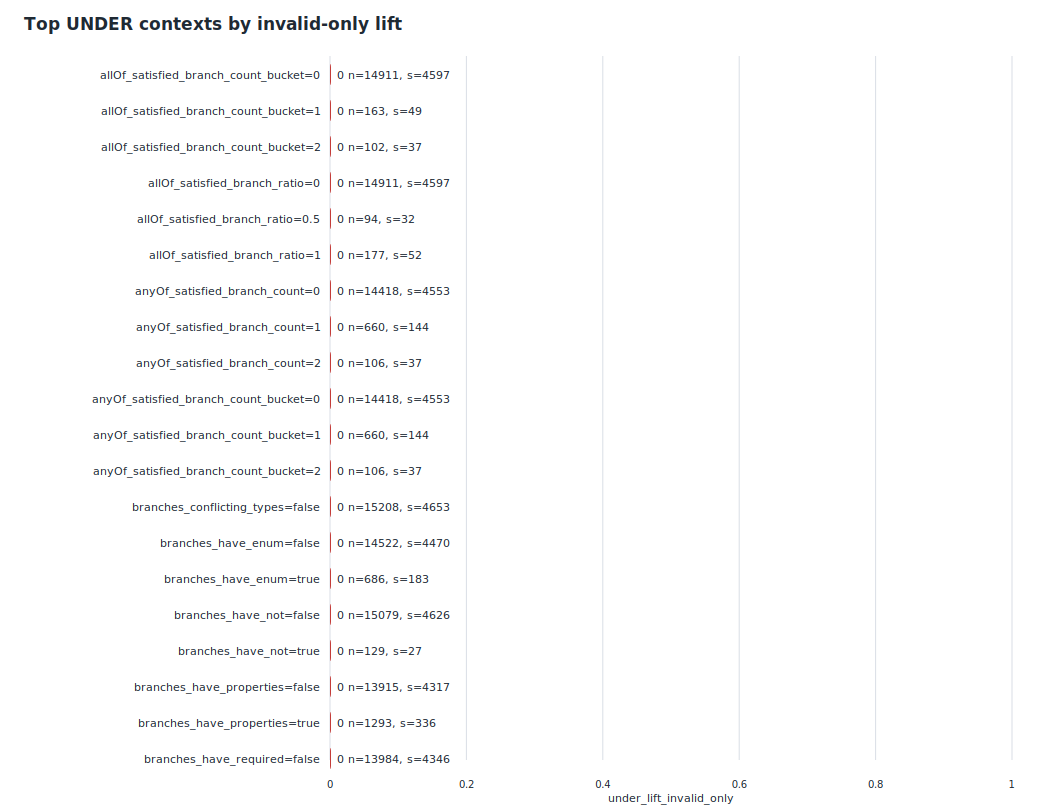

**top20_over_lift_valid_only.svg**

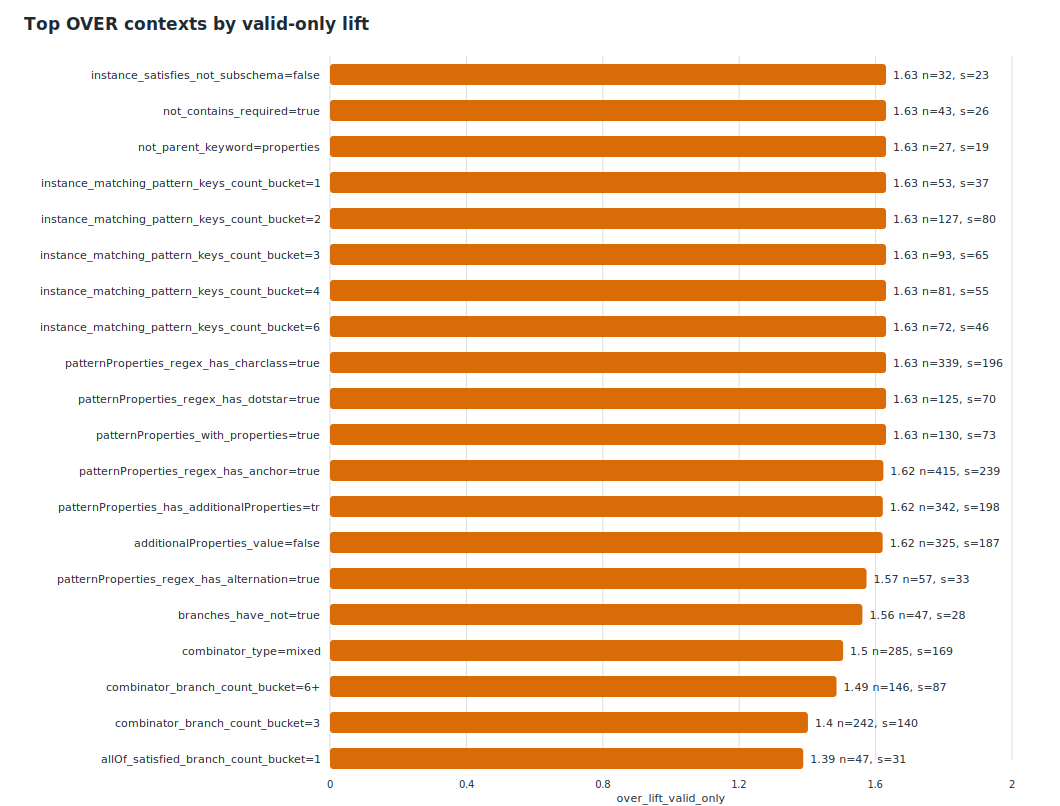

**support_vs_under_lift_invalid_only.svg**

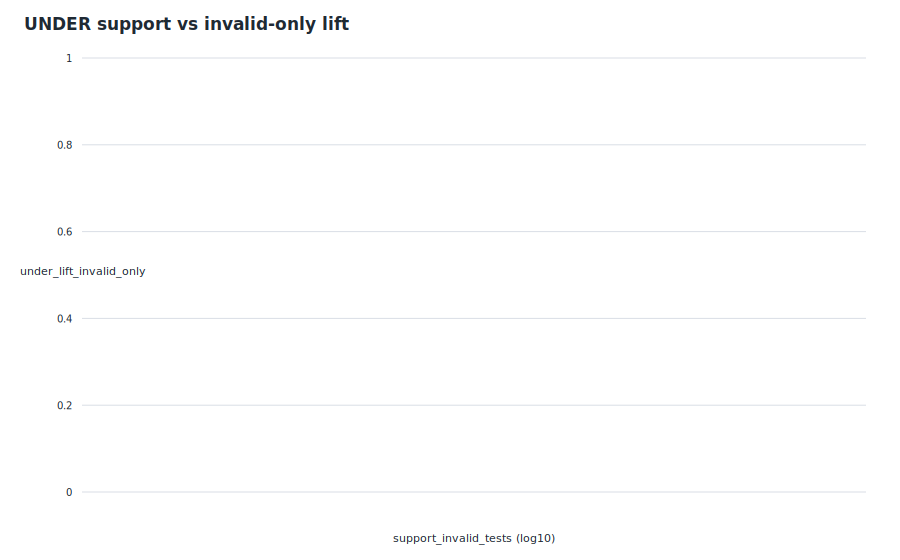

**support_vs_over_lift_valid_only.svg**

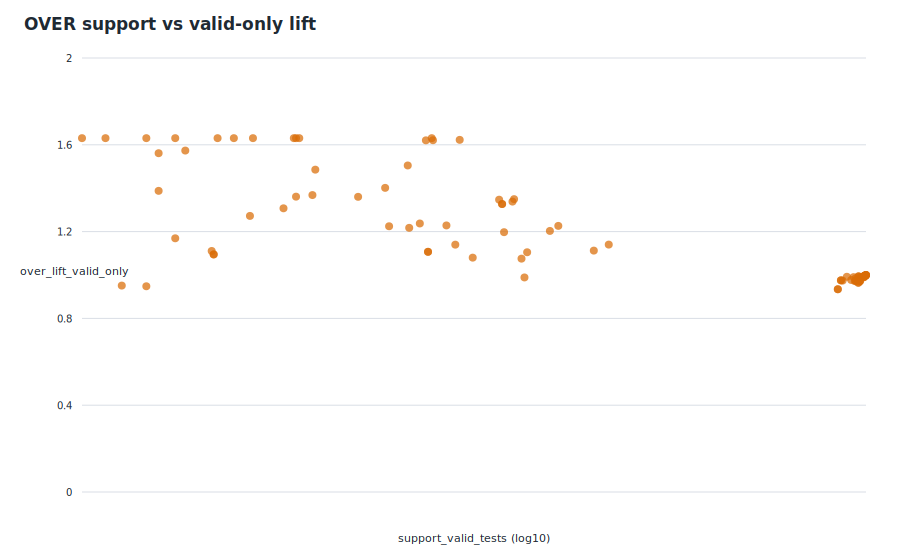

**cooccurrence_under_schemas.svg**

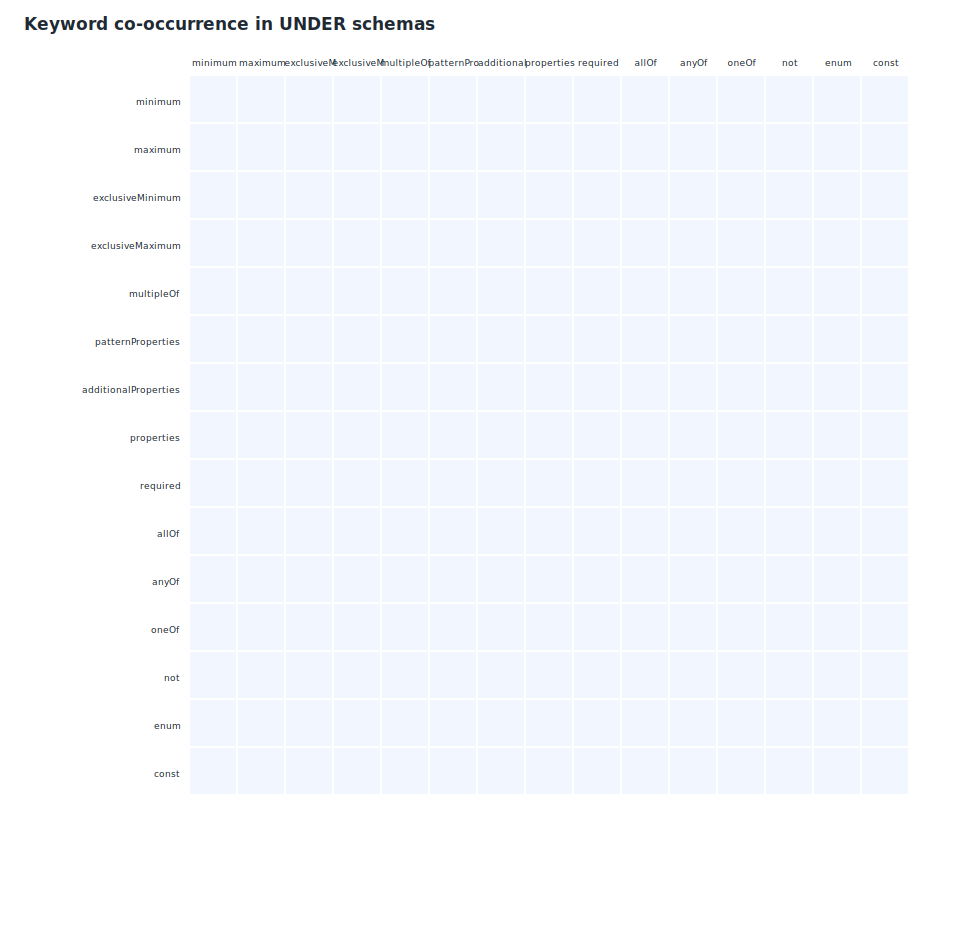

**cooccurrence_over_schemas.svg**

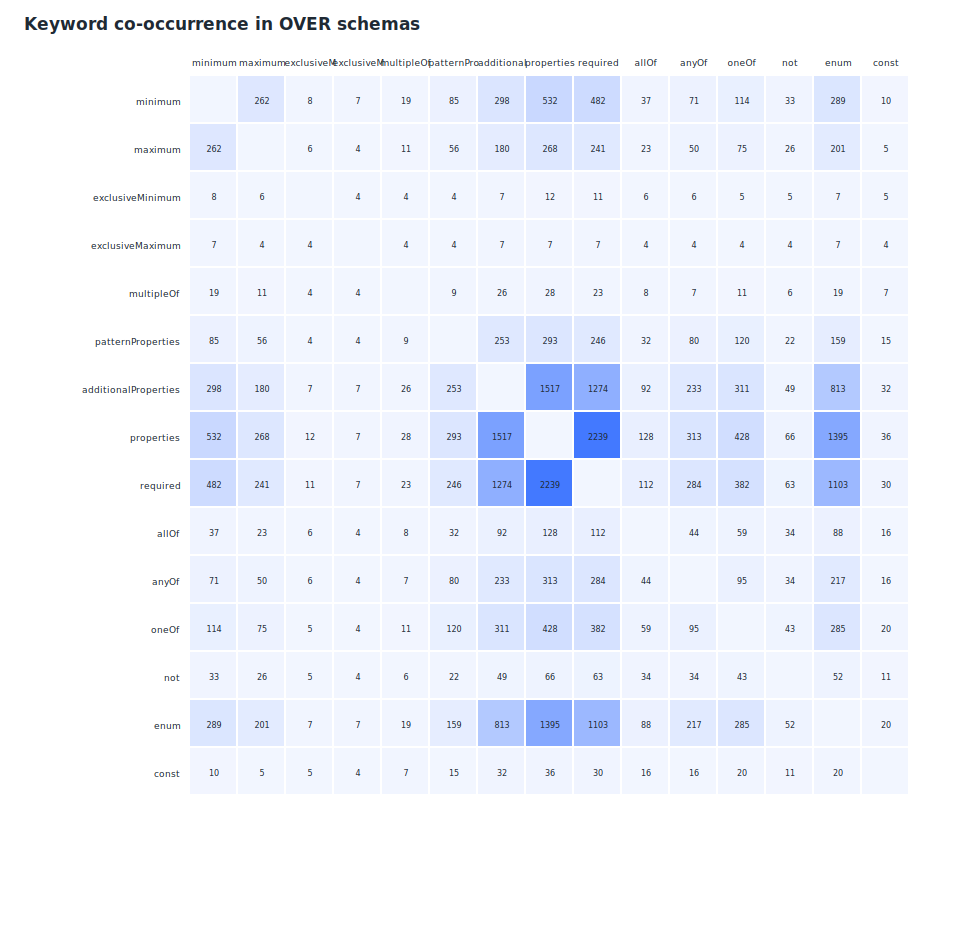

In [9]:
guidance_v2 = generate_refined_v2("guidance")
show_refined_v2_outputs(guidance_v2)


## Raffinée v2 — XGR

Cette cellule régénère les tables et les plots v2 pour `xgr` selon `DATASET_CHOICE`.

### Raffinée v2 — xgr / Github_global

Tables générées : `/home/berrais/stage/jsonschemabench/extension_jsonschemabench/notebook_outputs/refined_feature_analysis_v2/xgr/Github_global/tables`  
Plots générés : `/home/berrais/stage/jsonschemabench/extension_jsonschemabench/notebook_outputs/refined_feature_analysis_v2/xgr/Github_global/plots`

**Top contextes UNDER, invalid-only**

,context_family,context_feature,context_value,support_invalid_tests,support_schemas,under_count,under_rate_invalid_only,baseline_under_rate_invalid_only,under_lift_invalid_only,low_support
0,combinators,allOf_satisfied_branch_count_bucket,0,13877,4409,2002,0.144267,0.152375,0.946793,false
1,combinators,allOf_satisfied_branch_count_bucket,1,163,49,76,0.466258,0.152375,3.05994,false
2,combinators,allOf_satisfied_branch_count_bucket,2,97,36,66,0.680412,0.152375,4.46538,false
3,combinators,allOf_satisfied_branch_count_bucket,3,13,8,5,0.384615,0.152375,2.52414,true
4,combinators,allOf_satisfied_branch_count_bucket,4-5,18,4,10,0.555556,0.152375,3.64598,true
5,combinators,allOf_satisfied_branch_count_bucket,6+,1,1,0,0,0.152375,0,true
6,combinators,allOf_satisfied_branch_ratio,0,13877,4409,2002,0.144267,0.152375,0.946793,false
7,combinators,allOf_satisfied_branch_ratio,0.333333,2,2,1,0.5,0.152375,3.28138,true
8,combinators,allOf_satisfied_branch_ratio,0.5,94,32,59,0.62766,0.152375,4.11918,false
9,combinators,allOf_satisfied_branch_ratio,0.666667,19,10,17,0.894737,0.152375,5.87194,true


**Top contextes OVER, valid-only**

,context_family,context_feature,context_value,support_valid_tests,support_schemas,over_count,over_rate_valid_only,baseline_over_rate_valid_only,over_lift_valid_only,low_support
0,combinators,allOf_satisfied_branch_count_bucket,0,7406,4694,1443,0.194842,0.194979,0.999295,false
1,combinators,allOf_satisfied_branch_count_bucket,1,47,31,14,0.297872,0.194979,1.52771,false
2,combinators,allOf_satisfied_branch_count_bucket,2,51,31,5,0.0980392,0.194979,0.502818,false
3,combinators,allOf_satisfied_branch_count_bucket,3,17,10,2,0.117647,0.194979,0.603382,true
4,combinators,allOf_satisfied_branch_count_bucket,4-5,5,4,2,0.4,0.194979,2.0515,true
5,combinators,allOf_satisfied_branch_count_bucket,6+,3,2,2,0.666667,0.194979,3.41916,true
6,combinators,allOf_satisfied_branch_ratio,0,7406,4694,1443,0.194842,0.194979,0.999295,false
7,combinators,allOf_satisfied_branch_ratio,0.5,9,7,4,0.444444,0.194979,2.27944,true
8,combinators,allOf_satisfied_branch_ratio,1,114,71,21,0.184211,0.194979,0.944769,false
9,combinators,anyOf_satisfied_branch_count,0,7117,4516,1380,0.193902,0.194979,0.994474,false


**top20_under_lift_invalid_only.svg**

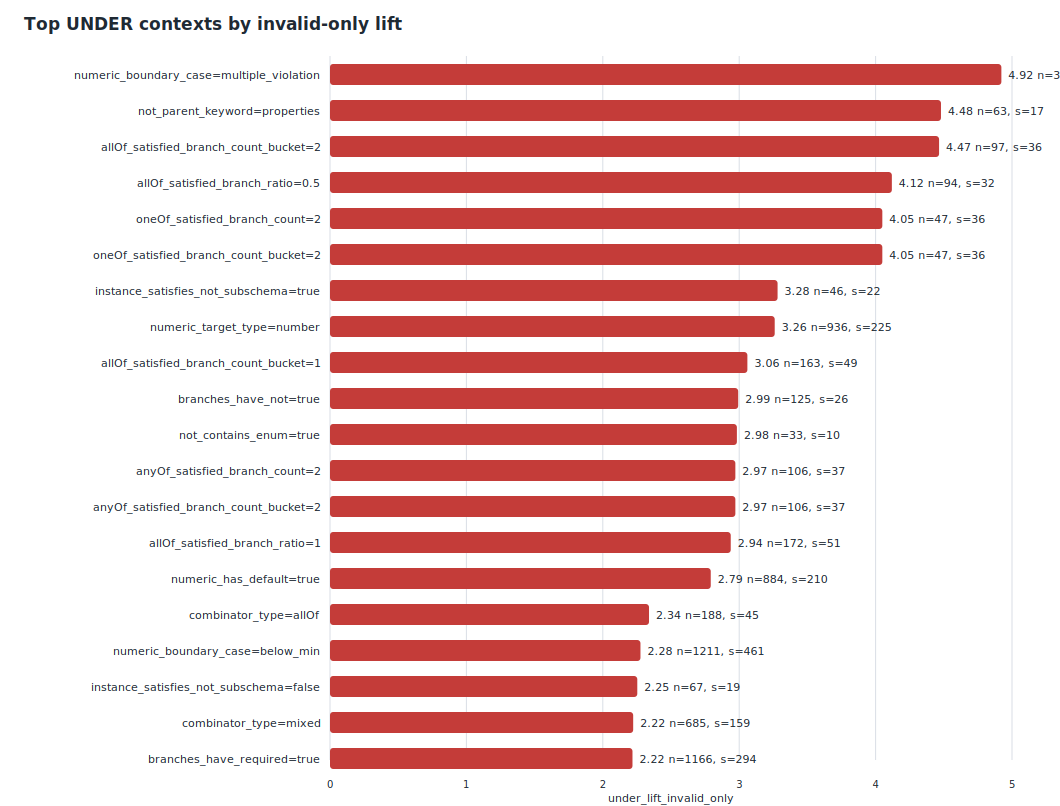

**top20_over_lift_valid_only.svg**

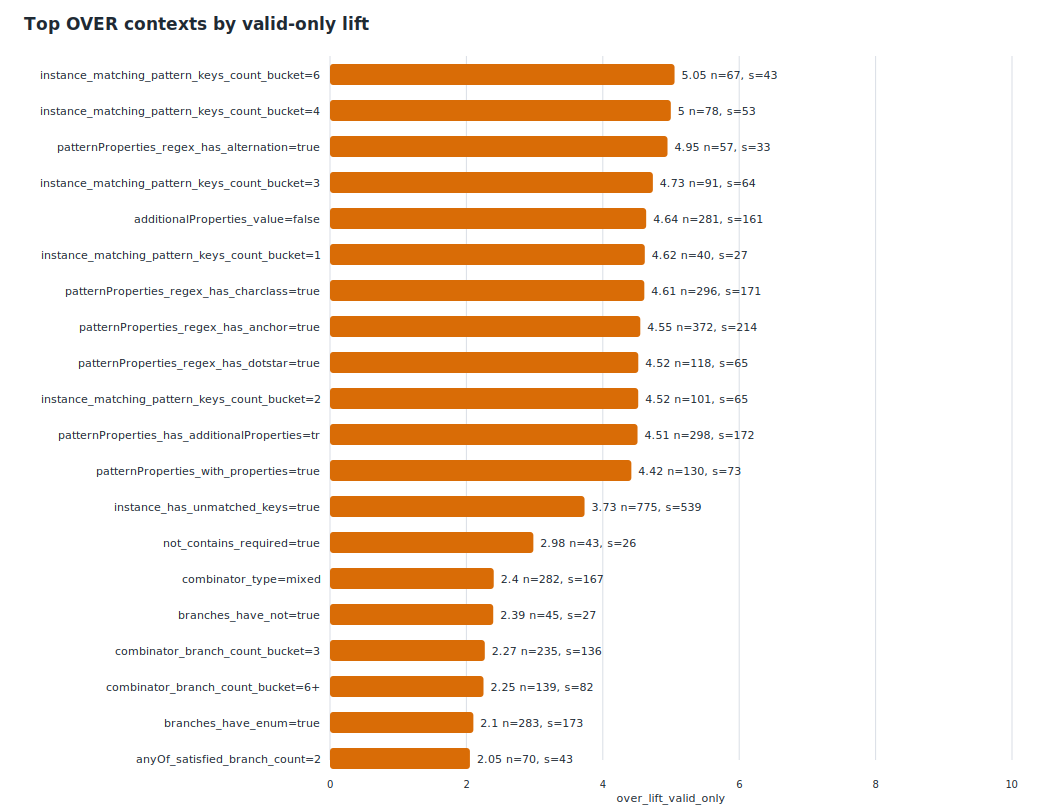

**support_vs_under_lift_invalid_only.svg**

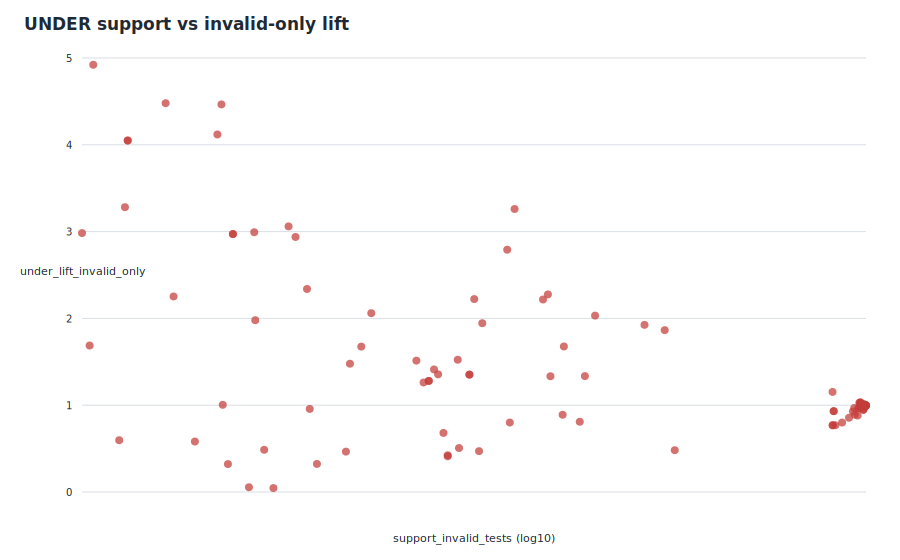

**support_vs_over_lift_valid_only.svg**

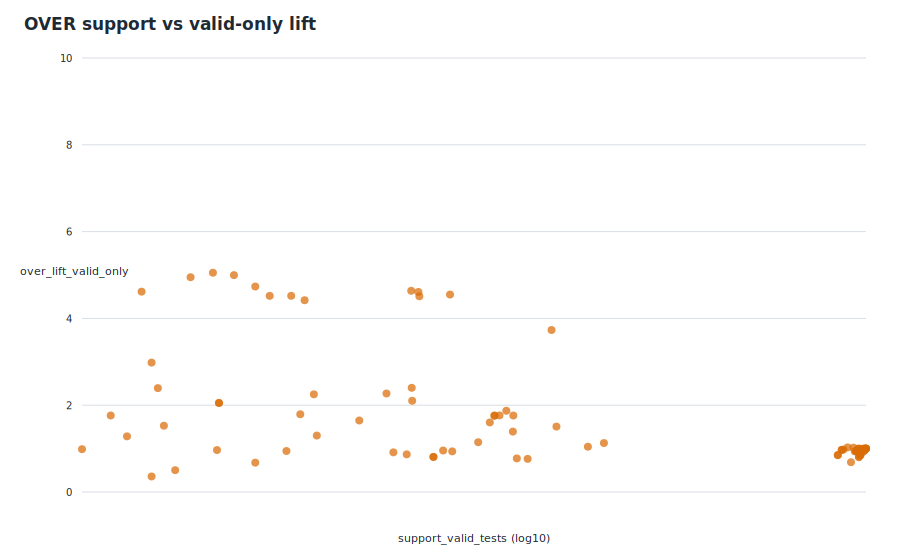

**cooccurrence_under_schemas.svg**

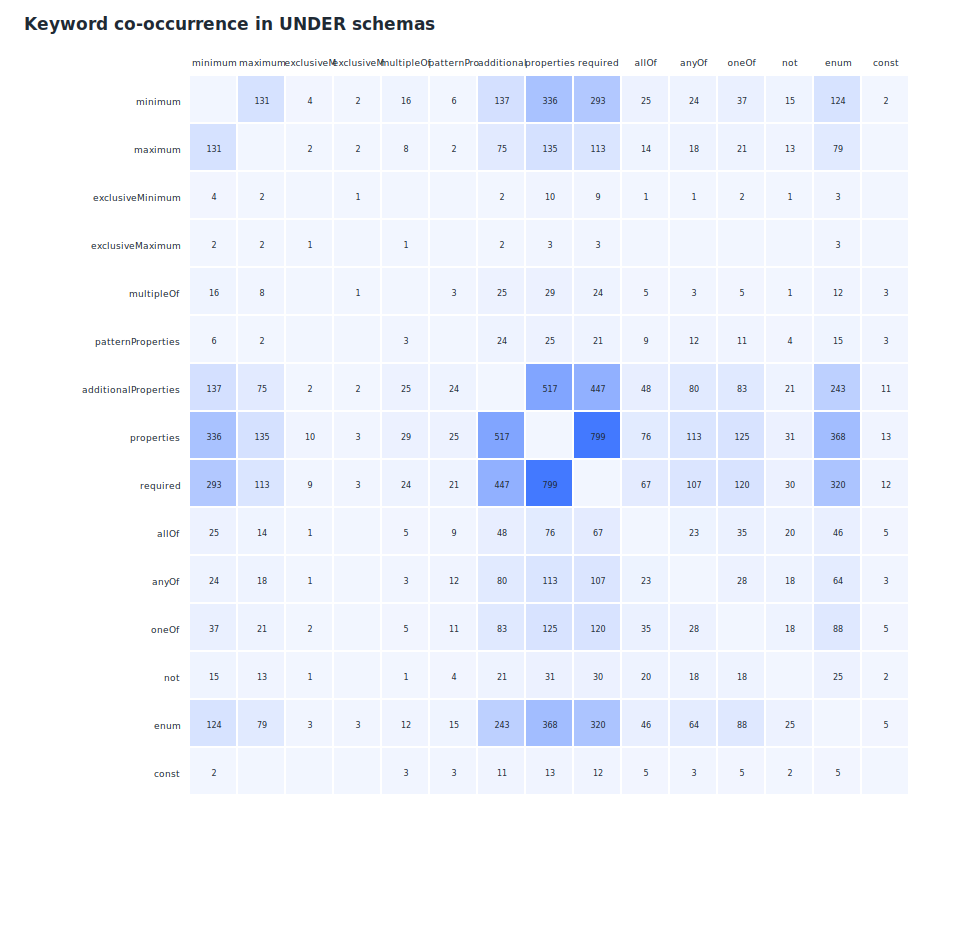

**cooccurrence_over_schemas.svg**

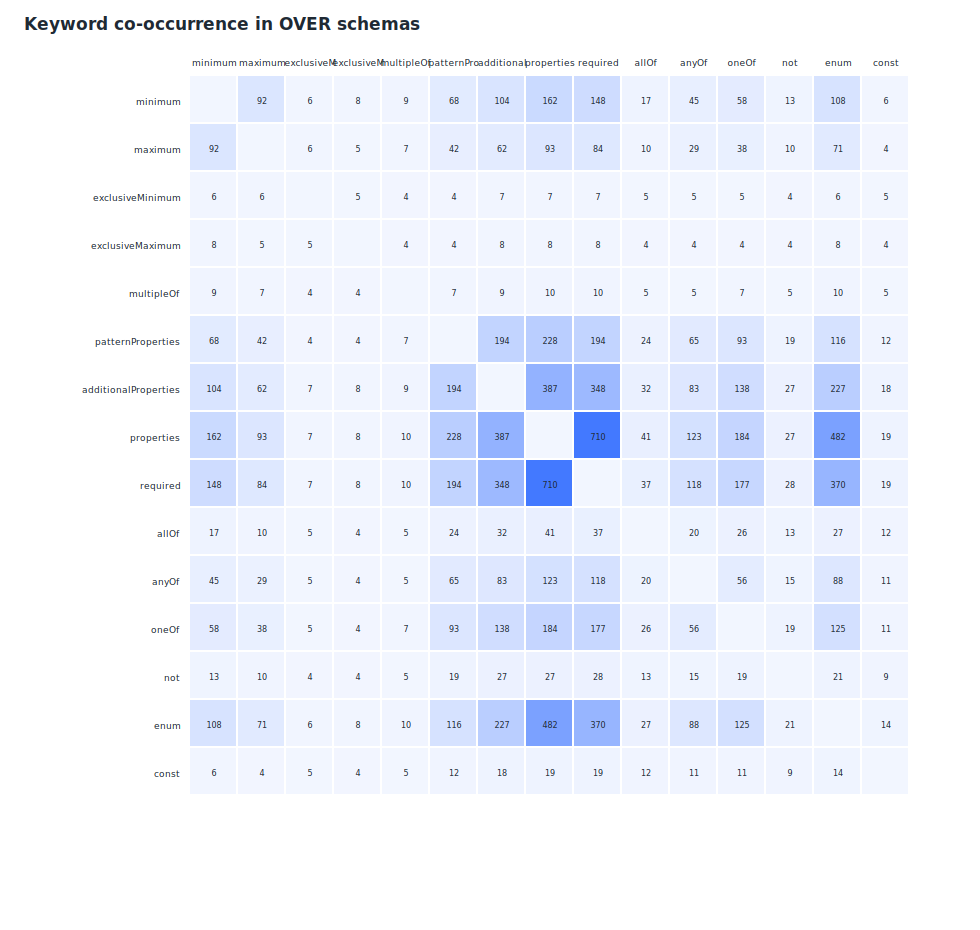

In [10]:
xgr_v2 = generate_refined_v2("xgr")
show_refined_v2_outputs(xgr_v2)


## Raffinée v2 — Outlines

Cette cellule régénère les tables et les plots v2 pour `outlines` selon `DATASET_CHOICE`. En mode global, elle utilise `Github_global_no_hard`.

In [ ]:
outlines_v2 = generate_refined_v2("outlines")
show_refined_v2_outputs(outlines_v2)


## Génération groupée optionnelle

Si vous préférez lancer la v2 pour tous les frameworks en une seule fois, utilisez cette cellule.

In [ ]:
v2_outputs = {}
for framework in FRAMEWORKS:
    try:
        info = generate_refined_v2(framework)
        v2_outputs[framework] = info
        print(f"OK {framework}/{info['dataset']} -> {info['output_plot_dir']}")
    except FileNotFoundError as exc:
        print(f"SKIP {framework}: {exc}")

v2_outputs


## Lecture rapide des résultats

- `under_invalid_only_risk.csv` : risque UNDER calculé uniquement parmi les tests invalides. C'est le bon dénominateur pour savoir quand le framework accepte trop facilement des instances invalides.
- `over_valid_only_risk.csv` : risque OVER calculé uniquement parmi les tests valides. C'est le bon dénominateur pour savoir quand le framework rejette trop strictement des instances valides.
- `schema_level_context_risk.csv` : la même idée, mais au niveau schéma, pour éviter qu'un petit nombre de schémas avec beaucoup de tests domine l'interprétation.
- `low_support=true` : contexte à lire avec prudence, car il n'y a pas assez de tests ou pas assez de schémas.

Pour comparer les frameworks, commencez par les plots `support_vs_*_lift` : ils montrent immédiatement si un signal est fort et bien supporté, ou seulement très élevé parce qu'il est rare.